# Machine Learning — Homework 4: Cross-validation, Pipelines and Leakage

**Course:** Machine Learning · **National University of Kyiv-Mohyla Academy (NaUKMA)**  
**Module 6:** Evaluation Done Properly (Week 6) · **Instructor:** Dmytro Kuzmenko

**Meta**

| Field | Value |
|---|---|
| Points | 5 (1.25 per task) |
| Estimated time | 2.5–3.5 hours |
| Prerequisites | Modules 1–5; sklearn `Pipeline`, `cross_val_score`, `KFold`, `GroupKFold` |
| Deadline | (placeholder — set on DistEdu) |

---

## AI Use Disclosure

Fill this in before submitting. Being honest here cannot lower your grade; hiding AI use and being caught can.

- **AI tools used:**
- **Nature of assistance:**
- **Representative prompts or relevant interaction:**
- **What I independently verified or changed:**

---

## Learning Objectives

- Explain why a single train/test split is a noisy estimate and how k-fold cross-validation stabilizes it.
- Choose stratified splitting for imbalanced targets and predict the consequences of ignoring it.
- Detect group-structured data and use `GroupKFold` to avoid group leakage.
- Build leakage-free preprocessing pipelines and identify optimistic scores caused by scaling, target, or encoding leakage.

---

## Warm-up

Run the setup cell. All random processes are seeded so your results match the numbers in the task text.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold, GroupKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

np.random.seed(42)
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
print("Setup complete.")

Setup complete.


### Task 1: One Split Is a Noisy Estimate — Cross-Validation Spread

**Experiment (A).** Train a decision tree (depth 5) on the breast cancer dataset — a deliberately *unstable* model, so the differences between estimates are easy to see. Evaluate it first on a **single** random 80/20 split, then with 5-fold cross-validation. We want two numbers: the single-split accuracy and the mean ± std of the 5 per-fold accuracies.

In [2]:
X, y = load_breast_cancer(return_X_y=True)
print("Dataset shape:", X.shape, "| positive rate: %.3f" % y.mean())

def make_model():
    return DecisionTreeClassifier(max_depth=5, random_state=42)

# Single 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = make_model()
model.fit(X_train, y_train)
single_acc = accuracy_score(y_test, model.predict(X_test))
print(f"Single 80/20 split accuracy: {single_acc:.4f}")

# 5-fold CV
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(make_model(), X, y, cv=cv, scoring="accuracy")
print(f"5-fold CV accuracy: {scores.mean():.4f} +/- {scores.std():.4f}")

Dataset shape: (569, 30) | positive rate: 0.627
Single 80/20 split accuracy: 0.9474
5-fold CV accuracy: 0.9420 +/- 0.0069


**Evidence (C).** Put both estimates and the per-fold results into one table so the spread is visible.

In [3]:
per_fold = pd.DataFrame({
    "fold": np.arange(1, 6),
    "accuracy": np.round(scores, 4),
})
summary = pd.DataFrame({
    "method": ["single 80/20 split", "5-fold CV mean", "5-fold CV std"],
    "accuracy": [round(single_acc, 4), round(scores.mean(), 4), round(scores.std(), 4)],
})
display(per_fold)
print()
display(summary)

,fold,accuracy
0,1,0.9474
1,2,0.9386
2,3,0.9298
3,4,0.9474
4,5,0.9469


,method,accuracy
0,single 80/20 split,0.9474
1,5-fold CV mean,0.9420
2,5-fold CV std,0.0069


**Your answer:**

**Your answer:**

**Your answer:**

20 single-split accuracies: min 0.8947, max 0.9649, std 0.0229
5-fold CV std: 0.0069


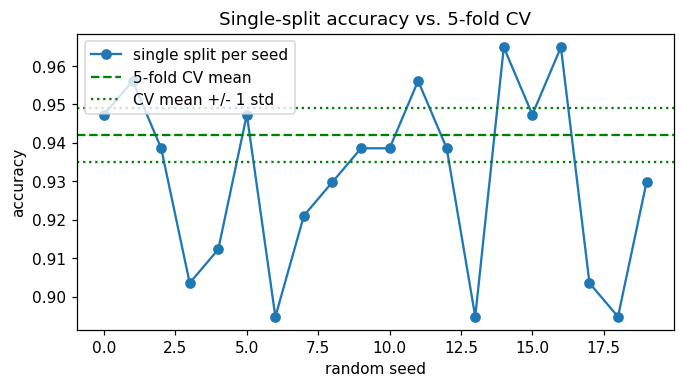

In [4]:
# Counterfactual verification: 20 single splits with different seeds
accs = []
for seed in range(20):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed)
    m = make_model()
    m.fit(X_tr, y_tr)
    accs.append(accuracy_score(y_te, m.predict(X_te)))

print("20 single-split accuracies: min %.4f, max %.4f, std %.4f" % (min(accs), max(accs), np.std(accs)))
print("5-fold CV std: %.4f" % scores.std())
plt.figure(figsize=(7, 3.5))
plt.plot(accs, "o-", label="single split per seed")
plt.axhline(scores.mean(), color="green", ls="--", label="5-fold CV mean")
plt.axhline(scores.mean() + scores.std(), color="green", ls=":", label="CV mean +/- 1 std")
plt.axhline(scores.mean() - scores.std(), color="green", ls=":")
plt.xlabel("random seed"); plt.ylabel("accuracy"); plt.legend()
plt.title("Single-split accuracy vs. 5-fold CV")
plt.show()

**Your answer:**

### Task 2: Stratification — Imbalanced Data and Empty Folds

**Experiment (A).** Build an imbalanced binary problem with 10% positives. Compare how `KFold` and `StratifiedKFold` distribute the positive class across the 5 test folds.

In [5]:
X_imb, y_imb = make_classification(n_samples=1000, n_features=8, n_informative=6,
                                     n_redundant=0, weights=[0.9, 0.1], random_state=42)
print("Overall positive rate: %.4f" % y_imb.mean())

kf = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def test_positive_rates(splitter, X, y):
    return np.array([y[te].mean() for tr, te in splitter.split(X, y)])

kf_rates = test_positive_rates(kf, X_imb, y_imb)
skf_rates = test_positive_rates(skf, X_imb, y_imb)
strat = pd.DataFrame({
    "fold": np.arange(1, 6),
    "KFold positive rate": np.round(kf_rates, 4),
    "StratifiedKFold positive rate": np.round(skf_rates, 4),
})
display(strat)

Overall positive rate: 0.1030


,fold,KFold positive rate,StratifiedKFold positive rate
0,1,0.115,0.100
1,2,0.135,0.100
2,3,0.110,0.105
3,4,0.075,0.105
4,5,0.080,0.105


**Evidence (C).** Quantify the imbalance risk: compute how far each fold's positive rate is from the overall rate for both splitters, and report the worst fold for each.

In [6]:
overall = y_imb.mean()
print("Overall positive rate: %.4f" % overall)
print("KFold worst deviation from overall: %.4f" % np.max(np.abs(kf_rates - overall)))
print("StratifiedKFold worst deviation: %.4f" % np.max(np.abs(skf_rates - overall)))

Overall positive rate: 0.1030
KFold worst deviation from overall: 0.0320
StratifiedKFold worst deviation: 0.0030


**Your answer:**

**Your answer:**

**Your answer:**

In [7]:
# Counterfactual verification: a fold with 0 positives in training
mask_pos = y_imb == 1
X_tr_no_pos = X_imb[~mask_pos]          # train only on negatives
y_tr_no_pos = y_imb[~mask_pos]
X_te = X_imb[mask_pos]                  # test only on positives
y_te = np.ones(len(X_te))

# A decision tree trains fine on a single-class training set (logistic regression would crash);
# its predictions show what a fold with no positives teaches the model.
m0 = DecisionTreeClassifier(max_depth=3, random_state=42)
m0.fit(X_tr_no_pos, y_tr_no_pos)
pred = m0.predict(X_te)
print("Test set: all positives. Predictions positive: %d / %d" % (pred.sum(), len(pred)))
print("Accuracy on all-positive test set: %.4f (recall of positives = %.4f)" % (accuracy_score(y_te, pred), (pred == 1).mean()))
print("Note: a classifier that never predicts the positive class still achieves %.2f accuracy on the full imbalanced data." % y_imb.mean())

Test set: all positives. Predictions positive: 0 / 103
Accuracy on all-positive test set: 0.0000 (recall of positives = 0.0000)
Note: a classifier that never predicts the positive class still achieves 0.10 accuracy on the full imbalanced data.


**Your answer:**

### Task 3: Group Leakage — Several Measurements per Patient

**Experiment (A).** Generate a realistic grouped dataset: 40 patients, 5 measurements each. The label is a *patient-level* property, while each measurement is a noisy view of the patient's hidden state plus a patient-specific baseline. We deliberately include an explicit patient-id column so the memorization mechanism is visible — then we check what happens without it. A naive split by measurement index puts measurements of the same patient into both train and test; a correct split never does.

In [8]:
def make_grouped(n_patients=40, n_measurements=5, seed=42, with_id=True):
    """Generate n_patients x n_measurements rows.
    The label is patient-level; features are a noisy view of the patient's
    latent state plus a patient-specific baseline (an implicit identity marker)."""
    rng = np.random.RandomState(seed)
    latent = rng.normal(0.0, 1.0, size=n_patients)       # patient-level hidden state
    baseline = rng.normal(0.0, 2.0, size=n_patients)     # patient-specific offset
    labels = (latent > 0).astype(int)
    X, y, groups = [], [], []
    for p in range(n_patients):
        for m in range(n_measurements):
            row = [latent[p] + rng.normal(0.0, 1.5), baseline[p] + rng.normal(0.0, 0.15)]
            if with_id:
                row.append(p)                            # explicit patient id column
            X.append(row); y.append(labels[p]); groups.append(p)
    return np.array(X, dtype=float), np.array(y), np.array(groups)

Xg, yg, groups = make_grouped(with_id=True)              # with an explicit id column
Xg_noid, yg_noid, groups_noid = make_grouped(with_id=False)  # same structure, no id column
print("Shape:", Xg.shape, "| patients:", len(np.unique(groups)), "| measurements per patient: 5")
print("Positive rate: %.3f" % yg.mean())

rf = RandomForestClassifier(n_estimators=100, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
gkf = GroupKFold(n_splits=5)

naive_id   = cross_val_score(rf, Xg, yg, cv=kf).mean()
group_id   = cross_val_score(rf, Xg, yg, cv=gkf, groups=groups).mean()
naive_noid = cross_val_score(rf, Xg_noid, yg_noid, cv=kf).mean()
group_noid = cross_val_score(rf, Xg_noid, yg_noid, cv=gkf, groups=groups_noid).mean()

print("WITH id column:  naive KFold %.4f | GroupKFold %.4f | gap %.4f" % (naive_id, group_id, naive_id - group_id))
print("WITHOUT id col:  naive KFold %.4f | GroupKFold %.4f | gap %.4f" % (naive_noid, group_noid, naive_noid - group_noid))

Shape: (200, 3) | patients: 40 | measurements per patient: 5
Positive rate: 0.400


WITH id column:  naive KFold 0.8450 | GroupKFold 0.5850 | gap 0.2600
WITHOUT id col:  naive KFold 0.7150 | GroupKFold 0.6100 | gap 0.1050


**Evidence (C).** Plot the four estimates and annotate the majority-class baseline.

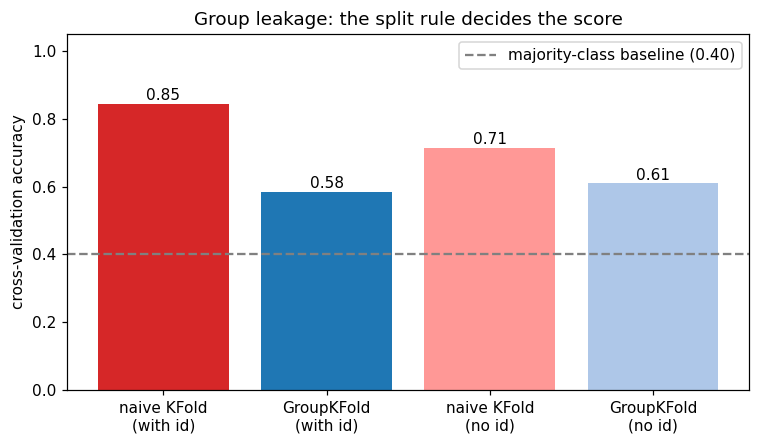

In [9]:
labels = ["naive KFold\n(with id)", "GroupKFold\n(with id)", "naive KFold\n(no id)", "GroupKFold\n(no id)"]
values = [naive_id, group_id, naive_noid, group_noid]
plt.figure(figsize=(8, 4.2))
bars = plt.bar(labels, values, color=["#d62728", "#1f77b4", "#ff9896", "#aec7e8"])
plt.axhline(yg.mean(), color="gray", ls="--", label="majority-class baseline (%.2f)" % yg.mean())
plt.ylabel("cross-validation accuracy"); plt.ylim(0, 1.05)
plt.title("Group leakage: the split rule decides the score")
plt.legend()
for b, v in zip(bars, values):
    plt.text(b.get_x() + b.get_width() / 2, v + 0.01, "%.2f" % v, ha="center")
plt.show()

**Your answer:**

**Your answer:**

**Your answer:**

In [10]:
# Counterfactual verification: 50 measurements per patient
Xg50, yg50, g50    = make_grouped(n_measurements=50, with_id=True)
Xg50n, yg50n, g50n = make_grouped(n_measurements=50, with_id=False)

naive50_id   = cross_val_score(rf, Xg50, yg50, cv=kf).mean()
group50_id   = cross_val_score(rf, Xg50, yg50, cv=gkf, groups=g50).mean()
naive50_noid = cross_val_score(rf, Xg50n, yg50n, cv=kf).mean()
group50_noid = cross_val_score(rf, Xg50n, yg50n, cv=gkf, groups=g50n).mean()

print("n_measurements = 50")
print("WITH id: naive %.4f | GroupKFold %.4f | gap %.4f" % (naive50_id, group50_id, naive50_id - group50_id))
print("NO id:   naive %.4f | GroupKFold %.4f | gap %.4f" % (naive50_noid, group50_noid, naive50_noid - group50_noid))
print("(n = 5 baseline gaps: with id %.4f, no id %.4f)" % (naive_id - group_id, naive_noid - group_noid))

n_measurements = 50
WITH id: naive 0.9810 | GroupKFold 0.4740 | gap 0.5070
NO id:   naive 0.7750 | GroupKFold 0.5825 | gap 0.1925
(n = 5 baseline gaps: with id 0.2600, no id 0.1050)


**Your answer:**

### Task 4: Pipeline Leakage — Scaling, Targets and Encoders

**Experiment (A).** Three families of leakage:

1. *Correct:* `StandardScaler` + logistic regression inside a `Pipeline`, evaluated with `cross_val_score` (the scaler sees only training rows) and tuned with `GridSearchCV`.
2. *Scaling leak:* `StandardScaler` fitted on the **full** dataset before any split, then CV on the transformed data. We add one outrageous outlier column so the mechanism is concrete.
3. *Target leaks:* (a) a copy of the target as a feature; (b) a mean-target encoding — the average label per patient — computed on the **full** grouped data from Task 3, so the encoding already contains the labels of rows that will later land in the test folds.

In [11]:
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)

def lr_pipeline():
    return Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(max_iter=1000))])

# (1) correct: preprocessing and model inside one pipeline; CV owns the fitting
correct_scores = cross_val_score(lr_pipeline(), X, y, cv=cv5, scoring="accuracy")
grid = GridSearchCV(lr_pipeline(), {"lr__C": [0.01, 0.1, 1.0, 10.0]}, cv=cv5, scoring="accuracy")
grid.fit(X, y)
print("CORRECT pipeline, 5-fold CV accuracy: %.4f +/- %.4f" % (correct_scores.mean(), correct_scores.std()))
print("GridSearchCV best C = %.2f, best CV accuracy = %.4f" % (grid.best_params_["lr__C"], grid.best_score_))

CORRECT pipeline, 5-fold CV accuracy: 0.9771 +/- 0.0090
GridSearchCV best C = 1.00, best CV accuracy = 0.9771


In [12]:
# (2) scaling leak: the scaler is fitted on ALL rows, including future "test" rows
X_out = np.column_stack([X, np.zeros(len(X))])
X_out[0, -1] = 1000.0                       # one extreme outlier in the extra column

full_scaler = StandardScaler().fit(X_out)   # <- sees every row, test rows included
X_scaled_full = full_scaler.transform(X_out)

leaky_scaling_lr = cross_val_score(lr_pipeline(), X_scaled_full, y, cv=cv5, scoring="accuracy").mean()
clean_scaling_lr = cross_val_score(lr_pipeline(), X_out, y, cv=cv5, scoring="accuracy").mean()
print("LR  | scaler on FULL data: %.4f | scaler in pipeline: %.4f | bias %.4f" %
      (leaky_scaling_lr, clean_scaling_lr, leaky_scaling_lr - clean_scaling_lr))

# kNN is more sensitive to scaling; check it too
def knn_pipeline():
    return Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=5))])
leaky_scaling_knn = cross_val_score(knn_pipeline(), X_scaled_full, y, cv=cv5, scoring="accuracy").mean()
clean_scaling_knn = cross_val_score(knn_pipeline(), X_out, y, cv=cv5, scoring="accuracy").mean()
print("kNN | scaler on FULL data: %.4f | scaler in pipeline: %.4f | bias %.4f" %
      (leaky_scaling_knn, clean_scaling_knn, leaky_scaling_knn - clean_scaling_knn))
print("On this dataset the scaling-leak bias is ~0: the features already sit on comparable\n"
      "scales and the folds are large, so the mean/std barely change when test rows are included.\n"
      "The bias is uncontrolled, though: with small samples, outliers or distribution shift it can\n"
      "move the estimate in either direction. The rule is simple - the scaler must never see test rows.")

LR  | scaler on FULL data: 0.9771 | scaler in pipeline: 0.9771 | bias 0.0000


kNN | scaler on FULL data: 0.9595 | scaler in pipeline: 0.9595 | bias 0.0000
On this dataset the scaling-leak bias is ~0: the features already sit on comparable
scales and the folds are large, so the mean/std barely change when test rows are included.
The bias is uncontrolled, though: with small samples, outliers or distribution shift it can
move the estimate in either direction. The rule is simple - the scaler must never see test rows.


In [13]:
# (3a) target copy: the label itself as a feature
X_tar = np.column_stack([X, y])
leaky_target = cross_val_score(DecisionTreeClassifier(max_depth=2, random_state=42), X_tar, y,
                               cv=cv5, scoring="accuracy").mean()
print("Target copy as a feature (decision tree, depth 2): %.4f" % leaky_target)

# (3b) mean-target encoding computed on the FULL grouped data: average label per patient
enc_full = pd.Series(yg).groupby(Xg[:, 2]).transform("mean").values
X_enc = np.column_stack([Xg, enc_full])
naive_enc = cross_val_score(rf, X_enc, yg, cv=kf, scoring="accuracy").mean()
group_enc = cross_val_score(rf, X_enc, yg, cv=gkf, groups=groups, scoring="accuracy").mean()
print("Mean-target encoding (per patient), naive KFold: %.4f" % naive_enc)
print("Mean-target encoding (per patient), GroupKFold: %.4f" % group_enc)
print("The encoding leaks through BOTH split rules: every test row's encoding was computed\n"
      "from the full data - i.e. from its own label. The only fix is to compute the encoding\n"
      "on training folds only, inside a pipeline / nested CV.")

Target copy as a feature (decision tree, depth 2): 1.0000


Mean-target encoding (per patient), naive KFold: 1.0000
Mean-target encoding (per patient), GroupKFold: 1.0000
The encoding leaks through BOTH split rules: every test row's encoding was computed
from the full data - i.e. from its own label. The only fix is to compute the encoding
on training folds only, inside a pipeline / nested CV.


**Evidence (C).** Collect all seven numbers into one comparison table.

In [14]:
summary4 = pd.DataFrame({
    "variant": ["correct pipeline (CV)", "correct pipeline (GridSearchCV best)",
                "scaling leak, LR", "scaling leak, kNN",
                "target copy (DT)", "mean-target encoding, naive KFold", "mean-target encoding, GroupKFold"],
    "accuracy": [correct_scores.mean(), grid.best_score_, leaky_scaling_lr, leaky_scaling_knn,
                 leaky_target, naive_enc, group_enc],
})
display(summary4.round(4))

,variant,accuracy
0,correct pipeline (CV),0.9771
1,correct pipeline (GridSearchCV best),0.9771
2,"scaling leak, LR",0.9771
3,"scaling leak, kNN",0.9595
4,target copy (DT),1.0000
5,"mean-target encoding, naive KFold",1.0000
6,"mean-target encoding, GroupKFold",1.0000


**Your answer:**

**Your answer:**

**Your answer:**

---

## Discussion Questions

1. Your teammate runs `GridSearchCV` with `cv=3` and reports the best score as "the accuracy of the model". What is wrong with that number, and what extra step makes it honest?
2. When would it be legitimate to *not* use `GroupKFold` even though the data has group structure?
3. A colleague says: "I always standardize the whole dataset first, it is just preprocessing." How would you convince them this can be a leakage in a nested-CV setting?

## Takeaways

- A single split is one draw from a noisy distribution; k-fold CV reports a mean **and** a spread, and both matter.
- Stratification keeps every fold representative when classes are imbalanced; an empty fold hides failure behind accuracy.
- If rows are grouped (patients, sessions, documents), split by group — otherwise the model is graded on memorization, not generalization.
- Any preprocessing step that sees test rows before the split leaks information; put every transform inside a `Pipeline` and let CV own the fitting.
